In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Part (a): Qualitative Analysis**

**Part (i):**

In [4]:
# Potential
def V(x):
    if abs(x) <= a:
        return -V0*np.sqrt(a**2 - x**2)
    else:
        return 0

# Parameters
a = 1
V0 = 10

# Space-grid
xi, xf = -3, 3
dx = 1e-2
N = int((xf-xi)/dx) + 1
xs = np.linspace(xi, xf, N)

# Potential values
Vs = [V(x) for x in xs]

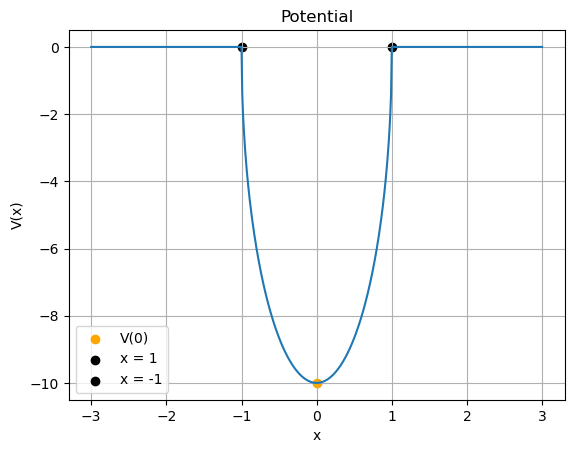

In [8]:
plt.plot(xs, Vs)
plt.scatter(0, -V0, color = "orange", label = "V(0)")
plt.scatter(1, V(1), color = "black", label = "x = 1")
plt.scatter(-1, V(-1), color = "black", label = "x = -1")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Potential")

plt.legend()
plt.grid()
plt.show()

The Schrodinger's equation in reduced form:
$$\psi''(x) = [V(x) - E] \psi(x)$$

For bound states, the wavefunction satisfies $\psi(x) \rightarrow 0$ as $x \rightarrow \infty$. Hence, we look for such states outside the well.

Outside the well, $V(x) = 0$. The Schrodinger's equation simplifies to:
$$\psi'' = -E\psi$$

**Case 1: $E \ge 0$**

$$\psi'' + E\psi = 0$$
This gives a general solution of the form:
$$\psi(x) = A\,e^{i\sqrt{E}x} + B\,e^{-i\sqrt{E}x}$$

It is an oscillatory solution and does not decay. Hence, it is not a bound state.

**Case 2: $E < 0$**

$$\psi'' = -E\psi = -(-|E|)\psi = |E|\psi$$
This gives a general solution of the form:
$$\psi(x) = A\,e^{\kappa x} + B\,e^{-\kappa x}$$
where $\kappa = \sqrt{|E|} = \sqrt{-E}$.

For decaying solutions:
1. $x > a \implies A = 0$
2. $x < a \implies B = 0$

This can be combined and written as:
$$\psi(x) \sim e^{-\kappa |x|}$$
which gives a decaying solution. Hence, for bound states, $E < 0$.

**Why $E \ge V_0$?**

Inside the well, $V(x) > -V_0$. If $E<-V_0 \implies E<V(x)$. This means that there is no classically allowed region for the particle anywhere. The wavefunction vanishes everywhere. This is not a physically meaningful solution.

Hence, for bound states, $0 > E > -V_0$

**Part (ii):**

Asymptotic solution:
$$\psi(x) \sim e^{-\kappa |x|}$$

At $x = \pm 3$:
$$\psi(x) \sim e^{-3\kappa}$$

Since $E>0 \implies \kappa > 0 \implies \psi(\pm 3) \approx 0$. Hence $x = \pm 3$ is a good approximation for boundary condition.

## **Part (b): Shooting method**

We consider:

$\psi = y[0] \\
\psi' = y[1]$

The 2 differential equations are:
$$\frac{d\psi}{dt} = \psi' \implies \frac{dy[0]}{dt} = y[1] \\[10 pt]
\frac{d\psi'}{dt} = (V - E)\psi \implies \frac{dy[1]}{dt} = (V-E)y[0]$$

These can be combined and written as:
$$ \frac{d}{dt}
\begin{pmatrix}
    y[0] \\
    y[1]
\end{pmatrix} =
\begin{pmatrix}
    y[1] \\
    (V-E) y[0]
\end{pmatrix}
$$

In [9]:
# RK4
def rk4(f1, x, y, h, E):
    k1 = h * f1(x, y, E)
    k2 = h * f1(x + h / 2, y + k1 / 2, E)
    k3 = h * f1(x + h / 2, y + k2 / 2, E)
    k4 = h * f1(x + h, y + k3, E)
    return y + (k1 + 2 * k2 + 2 * k3 + k4) / 6

# RK4 caller
def caller(fn, y_ini, N, xs, h, E):
    y = y_ini
    ys = np.zeros((N, len(y_ini)), dtype=np.float64)

    for i in range(N):
        x = xs[i]
        ys[i, :] = y
        y = rk4(fn, x, y, h, E)
    return ys

# dv/dt
def f1(x, y, E):
    return np.array([y[1], (V(x)-E)*y[0]])

**Part (i):**

The RK4 integration function f1 uses $V(x)$, not $\frac{dV}{dx}$, hence it does not cause a problem even if $\frac{dV}{dx} \rightarrow \infty$

In [12]:
# Space grid for left integration
xm = 0.5
xil, xfl = -3, xm
dx = 1e-3
Nl = int((xfl - xil)/dx)+1
xsl = np.linspace(xil, xfl, Nl)

# Trial energy
E = -5		
kappa = np.sqrt(-E)
Y0l = np.array([np.exp(-3*kappa), kappa*np.exp(-3*kappa)])

# Implementing RK4
Ysl = caller(f1, Y0l, Nl, xsl, dx, E)

**Part (ii):**

At $x = \pm 1$, V(x) changes rapidly. RK4 assumes that the function is smooth. This assumption is broken. Hence, the integration must not be started at $x = \pm1$ 

In [13]:
xir, xfr = xm, 3
dx = 1e-3
Nr = int((xfr - xir)/dx)+1
xsr = np.linspace(xir, xfr, Nr)

# Trial energy
E = -5		
kappa = np.sqrt(-E)
Y0l = np.array([np.exp(-3*kappa), kappa*np.exp(-3*kappa)])

# Implementing RK4
Ysr = caller(f1, Y0l, Nl, xsl, dx, E)

**Part (iii):**

The Schrodinger equation is linear. Hence, the left and right solutions can differ by a constant. If we match $\psi$ and $\psi'$ separately at the matching point, then:
$$\psi_L(x_m) = C\psi_R(x_m) \\[10 pt]
\psi_L'(x_m) = C\psi_R'(x_m)$$

This means that we have to fix the normalisation constant beforehand, which is unknown. Instead, if we match the derivative $\frac{\psi'}{\psi}$ then:
$$\psi \rightarrow C\psi \\[10 pt]
\frac{\psi'}{\psi} = \frac{(C\psi)'}{C\psi} = \frac{\psi'}{\psi}$$

The normalisation constant does not alter the result.